In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [ ]:
df=pd.read_csv('European_Bank.csv')
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Preprocessing

# 1.  Handle missing values


In [ ]:
df.isnull().sum()  

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [ ]:
# Fill numerical missing values
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Computer HuB\AppData\Local\Temp\ipykernel_7608\1962363449.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Computer HuB\AppData\Local\Temp\ipykernel_7608\1962363449.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [ ]:
# ------------------------------------ find duplicates ------------------------------------

df.duplicated().sum()

np.int64(0)

In [ ]:
    # ------------------------------------find shape  ------------------------------------
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


(10000, 14)

# 2. Feature Engineering

In [ ]:
# Balance-to-Salary Ratio
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

# Product Density Indicator
df['ProductDensity'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# Engagement Product Interaction
df['EngagementProduct'] = (
    df['IsActiveMember'] *
    df['NumOfProducts']
)

# Age-Tenure Interaction
df['AgeTenure'] = (
    df['Age'] *
    df['Tenure']
)
df

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenure
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0.000000,0.333333,0,195
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0.564102,0.090909,1,350
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0.000000,0.125000,1,252
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,0.808222,0.500000,0,126


# data almost clean and ready for analysis

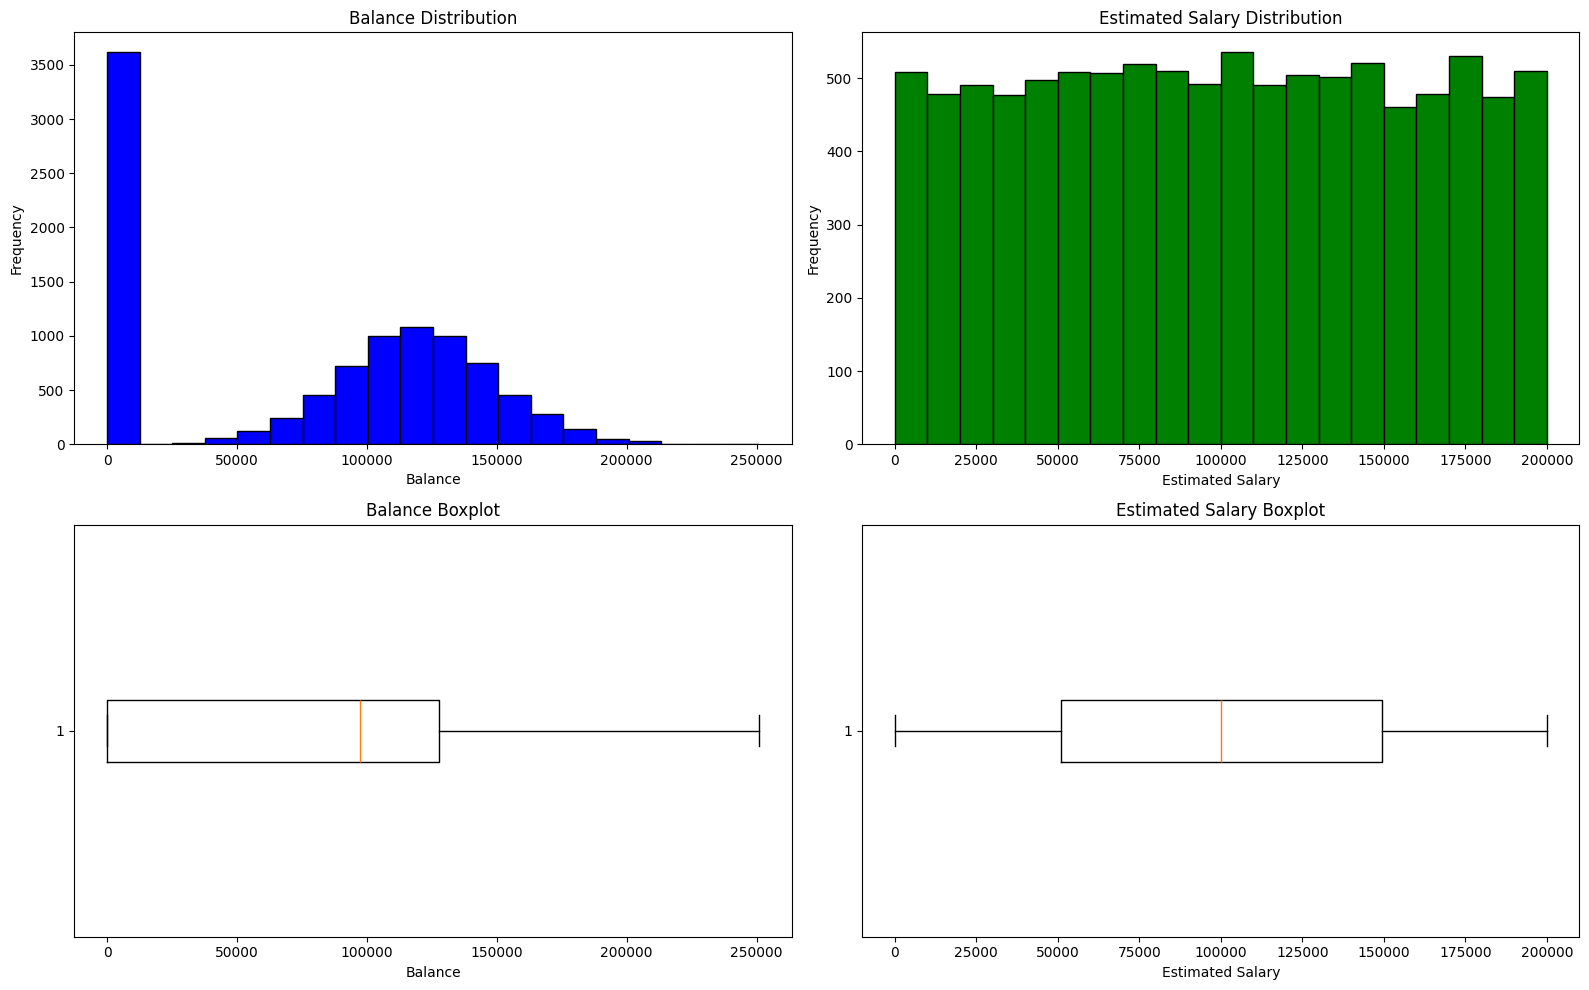

In [ ]:
figure, axes = plt.subplots(2,2, figsize=(16,10))
axes[0,0].hist(df['Balance'], bins=20, color='blue', edgecolor='black')
axes[0,0].set_title('Balance Distribution') 
axes[0,0].set_xlabel('Balance')
axes[0,0].set_ylabel('Frequency')
axes[0,1].hist(df['EstimatedSalary'], bins=20, color='green', edgecolor='black')
axes[0,1].set_title('Estimated Salary Distribution')
axes[0,1].set_xlabel('Estimated Salary')
axes[0,1].set_ylabel('Frequency')
axes[1,0].boxplot(df['Balance'], vert=False)
axes[1,0].set_title('Balance Boxplot')
axes[1,0].set_xlabel('Balance')
axes[1,1].boxplot(df['EstimatedSalary'], vert=False)
axes[1,1].set_title('Estimated Salary Boxplot')
axes[1,1].set_xlabel('Estimated Salary')
plt.tight_layout()


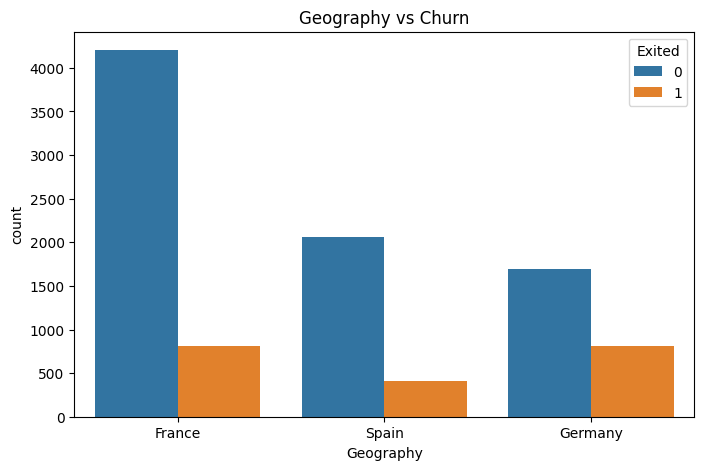

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title('Geography vs Churn')
plt.show()

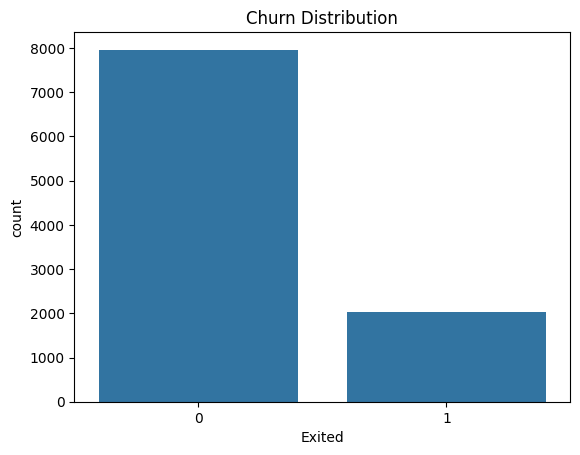

In [ ]:
# Visualization 2: Churn Distribution

sns.countplot(
    x='Exited',
    data=df
)

plt.title('Churn Distribution')
plt.show()

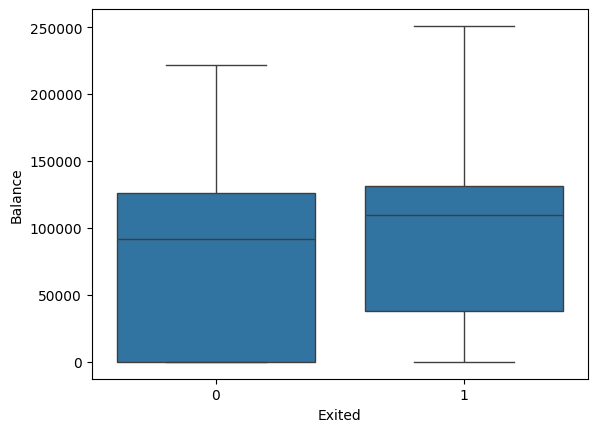

In [ ]:
sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.show()

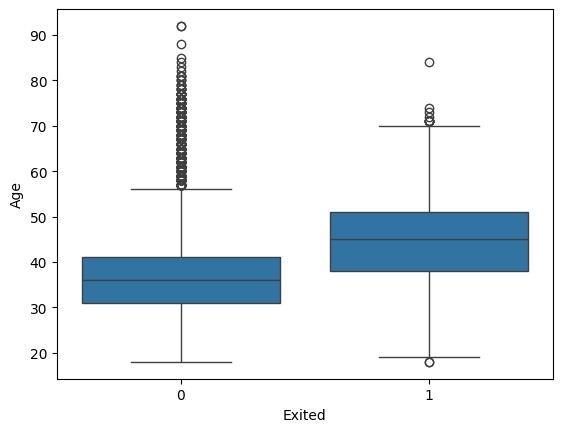

In [ ]:
sns.boxplot(
    x='Exited',
    y='Age',
    data=df
)

plt.show()

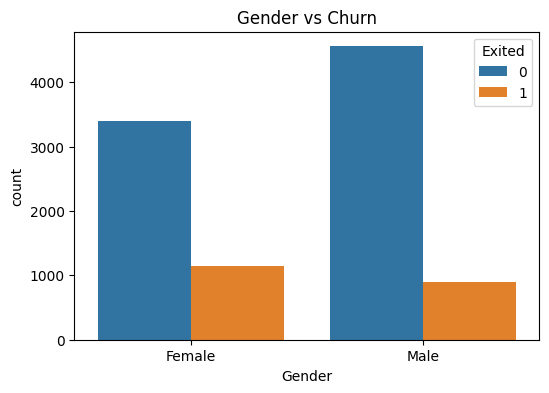

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    hue='Exited',
    data=df
)

plt.title('Gender vs Churn')
plt.show()

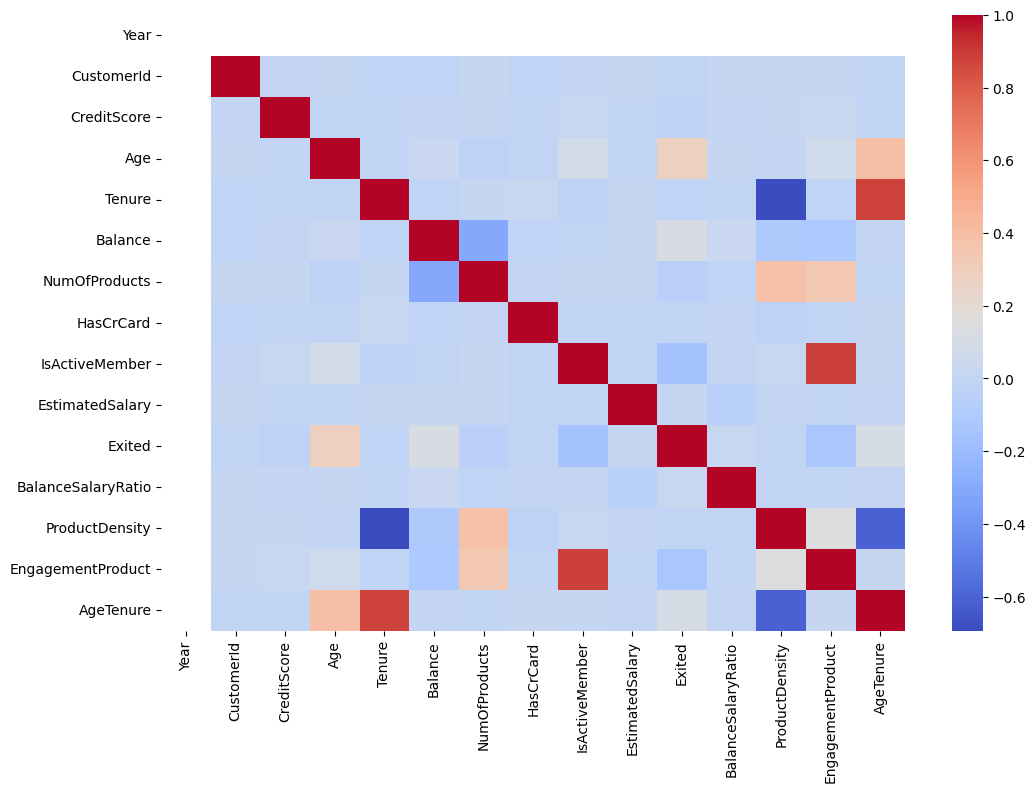

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.show()

In [ ]:
df['Balance'].value_counts()

Balance
0.00         3617
130170.82       2
105473.74       2
113957.01       1
85311.70        1
             ... 
88381.21        1
155060.41       1
57369.61        1
75075.31        1
116363.37       1
Name: count, Length: 6382, dtype: int64

# 2. Remove non-informative features (CustomerId, Surname)


In [ ]:


df.drop('CustomerId',axis=1,inplace=True)
df.drop('Surname',axis=1,inplace=True)


# 3. Encode categorical variables: One-hot encoding (Geography, Gender)

# One-hot encoding

In [ ]:

df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)
df


,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenure,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,771,39,5,0.00,2,1,0,96270.64,0,0.000000,0.333333,0,195,False,False,True
9996,2025,516,35,10,57369.61,1,1,1,101699.77,0,0.564102,0.090909,1,350,False,False,True
9997,2025,709,36,7,0.00,1,0,1,42085.58,1,0.000000,0.125000,1,252,False,False,False
9998,2025,772,42,3,75075.31,2,1,0,92888.52,1,0.808222,0.500000,0,126,True,False,True


# 4• Scale numerical features where required


In [ ]:
# Features and Target
X=df.drop('Exited',axis=1)
y=df['Exited']

In [ ]:
#  where X is input value and y is target value ----

print(X)
print(y)

      Year  CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0     2025          619   42       2       0.00              1          1   
1     2025          608   41       1   83807.86              1          0   
2     2025          502   42       8  159660.80              3          1   
3     2025          699   39       1       0.00              2          0   
4     2025          850   43       2  125510.82              1          1   
...    ...          ...  ...     ...        ...            ...        ...   
9995  2025          771   39       5       0.00              2          1   
9996  2025          516   35      10   57369.61              1          1   
9997  2025          709   36       7       0.00              1          0   
9998  2025          772   42       3   75075.31              2          1   
9999  2025          792   28       4  130142.79              1          1   

      IsActiveMember  EstimatedSalary  BalanceSalaryRatio  ProductDensity  

# 1. Stratified Train–Test Split 

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)# stratify=y -  Preserve churn distribution

In [ ]:
y_train

2151    1
8392    1
5006    0
4117    0
7182    0
       ..
4555    1
4644    0
8942    0
2935    0
6206    0
Name: Exited, Length: 8000, dtype: int64

# Feature scalling -------- Standardilization using StandardScaler class


In [ ]:
from sklearn.preprocessing import StandardScaler
# create object of StandardScaler
scaler=StandardScaler()

# fit the scaler on training data and transform both training and test data -------------learn only x_train sataset not x_test dataset because we want to avoid data leakage

scaler.fit(X_train)

# after fitting the scaler on training data, we can transform both training and test data

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(  X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape) 

print('before scaling X_train------------------------------------')

print(X_train)

print('before scaling X_test------------------------------------')

print(X_test)



print('after scaling X_train_scaler------------------------------------')

print(X_train_scaled)

print('after scaling X_test------------------------------------')

print(X_test_scaled)

(8000, 16) (8000,)
(2000, 16) (2000,)
before scaling X_train------------------------------------
      Year  CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
2151  2025          753   57       7       0.00              1          1   
8392  2025          739   32       3  102128.27              1          1   
5006  2025          755   37       0  113865.23              2          1   
4117  2025          561   37       5       0.00              2          1   
7182  2025          692   49       6  110540.43              2          0   
...    ...          ...  ...     ...        ...            ...        ...   
4555  2025          688   35       6       0.00              1          1   
4644  2025          712   74       5       0.00              2          0   
8942  2025          667   37       9   71786.90              2          1   
2935  2025          687   35       8  100988.39              2          1   
6206  2025          802   51       7       0.00         

In [ ]:
# after tained data dataset convert numpy array, so we can change it to dataframe for better understanding and visualization


X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_train_scaled_df.head()

NameError: name 'pd' is not defined

# Apply SMOTE

In [ ]:
# %pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())

c:\Users\Computer HuB\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Computer HuB\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Exited
0    6370
1    1630
Name: count, dtype: int64
Exited
1    6370
0    6370
Name: count, dtype: int64


##  Stratified K-Fold Cross Validation


In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_idx, test_idx in skf.split(X, y):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    print("Train Size:", len(X_train))
    print("Test Size:", len(X_test))

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=skf,
    scoring='roc_auc'
)

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Average ROC-AUC:", cv_scores.mean())

## Model Development

# 1 Logical Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lig=LogisticRegression()
lig.fit(X_train_scaled,y_train) 

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y_pred=lig.predict(X_test_scaled)
y_prob = lig.predict_proba(X_test_scaled)[:, 1]


In [ ]:
y_pred=lig.predict(X_train_scaled_df.iloc[[0]])
y_prob = lig.predict_proba(X_train_scaled_df.iloc[[0]])
print(y_pred[0])
print(y_prob[0])

train_acc=accuracy_score(y_train,y_prob )
print('train_acc',train_acc)
y_pred_cus=lig.predict(X_test_scaled_df.iloc[[0]])
y_prob_cus = lig.predict_proba(X_test_scaled_df.iloc[[0]])
print(y_pred_cus[0])
print(y_prob_cus[0])

test_acc=accuracy_score(y_test,y_prob_cus)
print('test_acc',test_acc)
gap=train_acc-test_acc
print('gap',gap)

# y_pred_cus=lig.predict(X_test_scaled_df.iloc[[1]])
# y_prob_cus = lig.predict_proba(X_test_scaled_df.iloc[[1]])
# print(y_pred_cus[0])
# print(y_prob_cus[0])


c:\Users\Computer HuB\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\Computer HuB\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0
[0.61225331 0.38774669]


ValueError: Found input variables with inconsistent numbers of samples: [8000, 1]

In [ ]:
print(df.iloc[[0]])
print(df.iloc[[1]])

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.0,1,1,1,101348.88,1


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
[[1535   58]
 [ 329   78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1593
           1       0.57      0.19      0.29       407

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.59      2000
weighted avg       0.77      0.81      0.77      2000


Accuracy Score:
0.8065

ROC-AUC Score: 0.773440620898248


# ● Random Forest


In [ ]:
# 1. Create Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)


# Step 2: 5-Fold Stratified CV
# =====================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

print("\nROC-AUC Score for each Fold:")
print(cv_scores)

print("\nAverage ROC-AUC Score:")
print(cv_scores.mean())



# 3. Train Model

model.fit(X_train_scaled, y_train)



ROC-AUC Score for each Fold:
[0.85141721 0.8669304  0.87058537 0.83811916 0.84847974]

Average ROC-AUC Score:
0.8551063747820977


,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# 4. Predictions

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 5. Evaluation

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.8395

ROC-AUC Score: 0.863737389161118

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.60      0.64      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000

Confusion Matrix:
[[1419  174]
 [ 147  260]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Decision Tree Model
# ==========================

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

# ==========================
# Train Model
# ==========================

dt_model.fit(X_train, y_train)

# ==========================
# Prediction
# ==========================

y_pred = dt_model.predict(X_test)

y_prob = dt_model.predict_proba(X_test)[:,1]

# ==========================
# Evaluation
# ==========================

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nPrecision:",
      precision_score(y_test, y_pred))

print("\nRecall:",
      recall_score(y_test, y_pred))

print("\nF1 Score:",
      f1_score(y_test, y_pred))

print("\nROC-AUC:",
      roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.858

Precision: 0.7662337662337663

Recall: 0.4348894348894349

F1 Score: 0.554858934169279

ROC-AUC: 0.8362376243732176

Confusion Matrix:
[[1539   54]
 [ 230  177]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [ ]:
# %pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test,y_pred))

print("Precision:",
      precision_score(y_test,y_pred))

print("Recall:",
      recall_score(y_test,y_pred))

print("F1 Score:",
      f1_score(y_test,y_pred))

print("ROC-AUC:",
      roc_auc_score(y_test,y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report")
print(classification_report(y_test,y_pred))

Accuracy: 0.8715
Precision: 0.7976190476190477
Recall: 0.49385749385749383
F1 Score: 0.6100151745068285
ROC-AUC: 0.8628705747349815

Confusion Matrix
[[1542   51]
 [ 206  201]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000



In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# ==========================================
# 11. Train Model
# ==========================================

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

# ==========================================
# 12. Predictions
# ==========================================

y_pred = xgb_model.predict(
    X_test_scaled
)

y_prob = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

# ==========================================
# 13. Evaluation
# ==========================================

print("\nAccuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1 Score:",
      f1_score(y_test, y_pred))

print("ROC-AUC Score:",
      roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# ==========================================



Accuracy: 0.8565
Precision: 0.6648351648351648
Recall: 0.5945945945945946
F1 Score: 0.6277561608300908
ROC-AUC Score: 0.8658165098843064

Confusion Matrix
[[1471  122]
 [ 165  242]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1593
           1       0.66      0.59      0.63       407

    accuracy                           0.86      2000
   macro avg       0.78      0.76      0.77      2000
weighted avg       0.85      0.86      0.85      2000



# Feature Importance

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

               Feature  Importance
2                  Age    0.380919
5        NumOfProducts    0.299832
7       IsActiveMember    0.120112
4              Balance    0.065567
13   Geography_Germany    0.054714
9   BalanceSalaryRatio    0.047329
8      EstimatedSalary    0.012290
12           AgeTenure    0.008357
1          CreditScore    0.007894
10      ProductDensity    0.002083


# Feature Importance Visualization

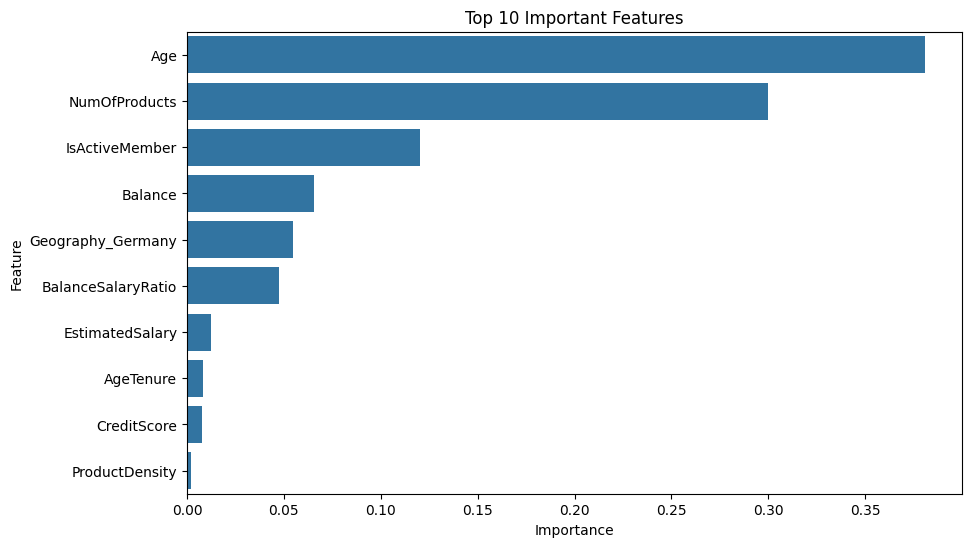

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(max_depth=6),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        eval_metric='logloss',
        random_state=42
    )
}

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, model in models.items():

    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred = model.predict(X_test_scaled)

    y_prob = model.predict_proba(
        X_test_scaled
    )[:,1]

    results.append([

        name,

        accuracy_score(y_test,y_pred),

        precision_score(y_test,y_pred),

        recall_score(y_test,y_pred),

        f1_score(y_test,y_pred),

        roc_auc_score(y_test,y_prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'
    ]
)

print(results_df)



                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression    0.7145   0.388283  0.700246  0.499562  0.775676
1        Decision Tree    0.7785   0.471787  0.739558  0.576077  0.830175
2        Random Forest    0.8420   0.615776  0.594595  0.605000  0.851683
3              XGBoost    0.8475   0.648256  0.547912  0.593875  0.839625


In [ ]:
# %pip install plotly
import plotly.graph_objects as go

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
colors = ['#8B00FF', '#008000', '#0000FF', '#FFA500']

fig = go.Figure()

for i, row in results_df.iterrows():
    fig.add_trace(go.Bar(
        name=row['Model'],
        x=metrics,
        y=[row[m] for m in metrics],
        marker_color=colors[i],
        hovertemplate='<b>%{fullData.name}</b><br>%{x}: %{y:.4f}<extra></extra>'
    ))

fig.update_layout(
    barmode='group',
    title='Model Comparison',
    yaxis=dict(title='Score', range=[0, 1.0]),
    xaxis=dict(title='Metric'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified',
    plot_bgcolor='white',
    bargap=0.2,
    bargroupgap=0.05
)

fig.update_yaxes(gridcolor='rgba(0,0,0,0.1)')

fig.show()

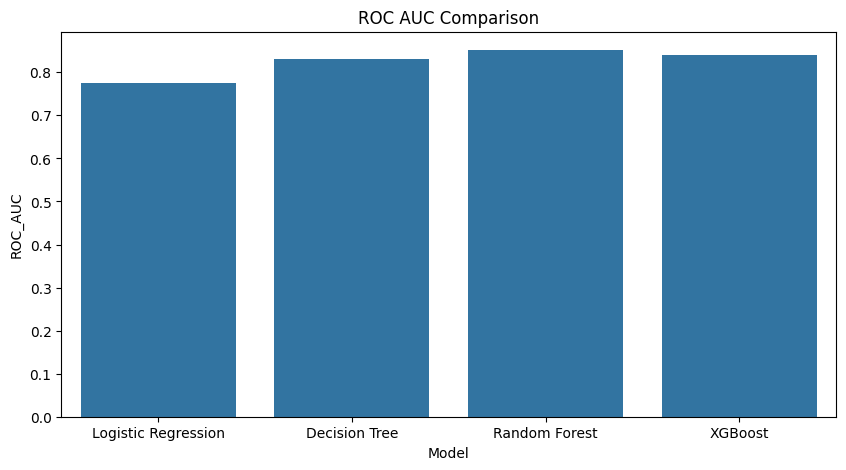

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='ROC_AUC',
    data=results_df
)

plt.title('ROC AUC Comparison')
plt.show()

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
train_results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train_smote)
    y_train_prob = model.predict_proba(X_train_smote)[:, 1]
    
    train_results.append([
        name,
        accuracy_score(y_train_smote, y_train_pred),
        precision_score(y_train_smote, y_train_pred),
        recall_score(y_train_smote, y_train_pred),
        f1_score(y_train_smote, y_train_pred),
        roc_auc_score(y_train_smote, y_train_prob)
    ])

train_df = pd.DataFrame(train_results, columns=['Model','Accuracy','Precision','Recall','F1','ROC_AUC'])

# Compare karo
print("=== TRAIN SCORES ===")
print(train_df.round(4))
print("\n=== TEST SCORES ===")
print(results_df.round(4))

print("\n=== DIFFERENCE (Train - Test) ===")
diff_df = train_df.copy()
diff_df[metrics] = train_df[metrics].values - results_df[metrics].values
print(diff_df.round(4))

=== TRAIN SCORES ===
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression    0.7133     0.7180  0.7024  0.7101   0.7782
1        Decision Tree    0.8118     0.8015  0.8289  0.8149   0.8856
2        Random Forest    1.0000     1.0000  1.0000  1.0000   1.0000
3              XGBoost    0.9707     0.9845  0.9565  0.9703   0.9961

=== TEST SCORES ===
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression    0.7145     0.3883  0.7002  0.4996   0.7757
1        Decision Tree    0.7785     0.4718  0.7396  0.5761   0.8302
2        Random Forest    0.8420     0.6158  0.5946  0.6050   0.8517
3              XGBoost    0.8475     0.6483  0.5479  0.5939   0.8396

=== DIFFERENCE (Train - Test) ===
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression   -0.0012     0.3297  0.0021  0.2105   0.0025
1        Decision Tree    0.0333     0.3297  0.0893  0.2389   0.0554
2        Random Forest    

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=10),

    # Random Forest - overfitting fix
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,           # unlimited tha, ab limit kar diya
        min_samples_leaf=10,   # har leaf me kam se kam 10 samples
        min_samples_split=20,  # split ke liye 20 samples chahiye
        max_features='sqrt',
        random_state=42
    ),

    # XGBoost - overfitting fix
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=4,           # depth kam ki
        learning_rate=0.05,    # slow learning
        subsample=0.8,         # har tree 80% data use kare
        colsample_bytree=0.8,  # har tree 80% features use kare
        reg_alpha=0.1,         # L1 regularization
        reg_lambda=1.5,        # L2 regularization
        random_state=42,
        eval_metric='logloss'
    )
}

In [ ]:
# ============================================
# STEP 1: Hyperparameter Tuning (XGBoost best hai)
# ============================================
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8]
}

xgb = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC:", grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.9}
Best ROC-AUC: 0.9624057037378411


Accuracy: 0.856
ROC-AUC: 0.8574475862611455

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1593
           1       0.68      0.56      0.61       407

    accuracy                           0.86      2000
   macro avg       0.78      0.75      0.76      2000
weighted avg       0.85      0.86      0.85      2000



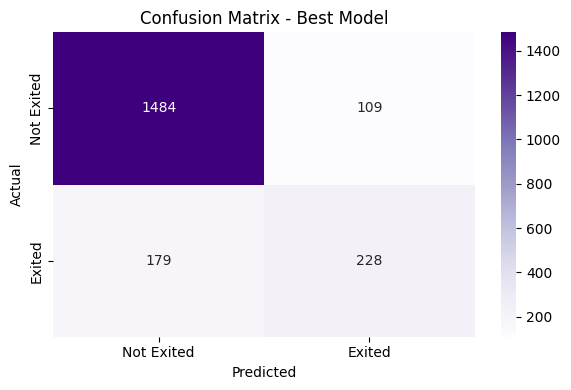

In [ ]:
# ============================================
# STEP 2: Final Evaluation best model pe
# ============================================
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Exited', 'Exited'],
            yticklabels=['Not Exited', 'Exited'])
plt.title('Confusion Matrix - Best Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

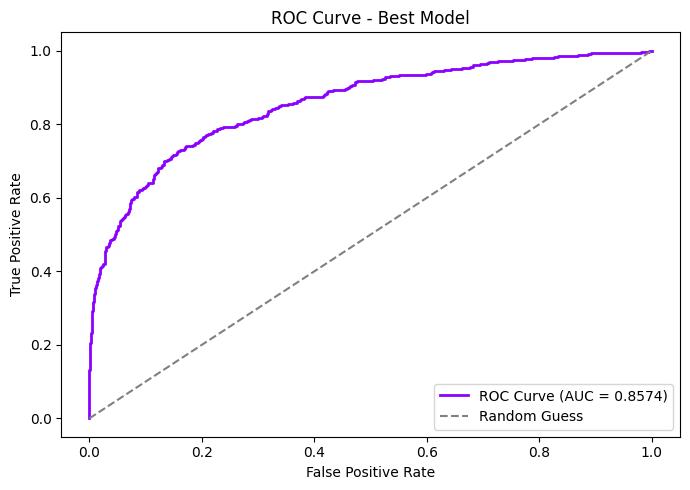

In [ ]:
# ============================================
# STEP 3: ROC Curve
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#8B00FF', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

C:\Users\Computer HuB\AppData\Local\Temp\ipykernel_7608\2800841001.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Purples_r')


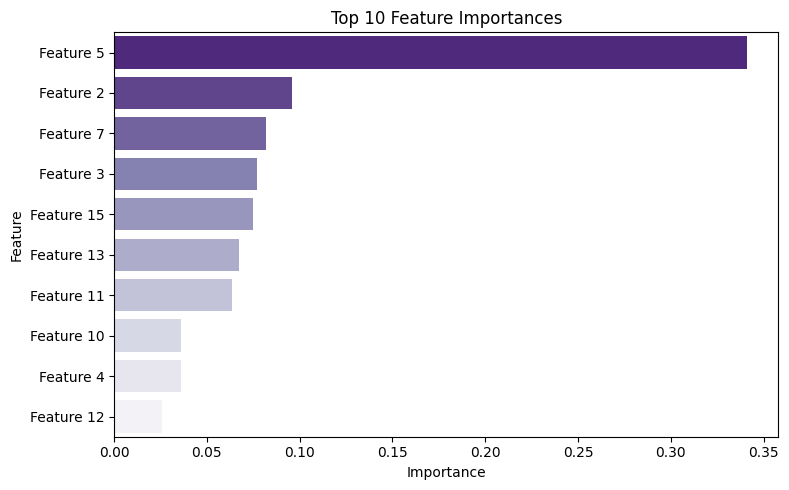

In [ ]:
# ============================================
# STEP 4: Feature Importance
# ============================================
feature_names = X_train_smote.columns if hasattr(X_train_smote, 'columns') else [f'Feature {i}' for i in range(X_train_smote.shape[1])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Purples_r')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# STEP 5: Model Save karo
# ============================================
import joblib

joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved!")

# Load karne ke liye:
# model = joblib.load('best_churn_model.pkl')
# scaler = joblib.load('scaler.pkl')

Model saved!


Best Threshold: 0.4369
Precision at best threshold: 0.6503
Recall at best threshold:    0.6167
F1 at best threshold:        0.6330


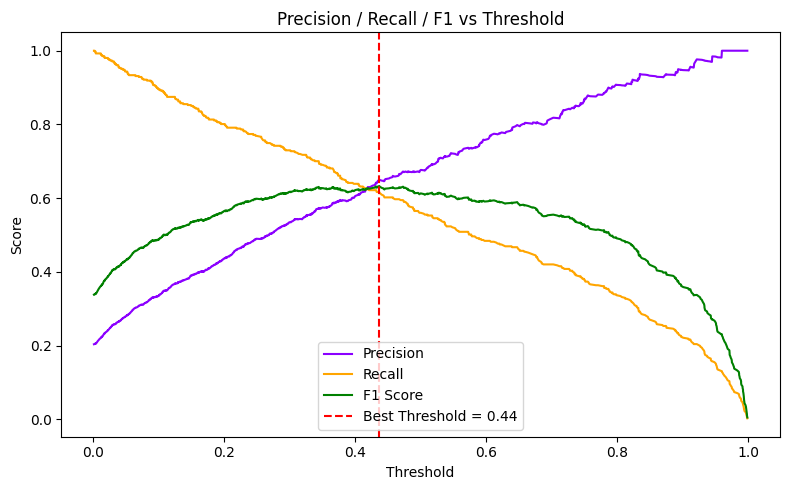

In [ ]:
# ============================================
# Threshold Tuning - Recall badhao class 1 ka
# ============================================
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

# Best threshold dhundo - F1 maximize karo
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Precision at best threshold: {precisions[best_idx]:.4f}")
print(f"Recall at best threshold:    {recalls[best_idx]:.4f}")
print(f"F1 at best threshold:        {f1_scores[best_idx]:.4f}")

# Precision-Recall curve plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], color='#8B00FF', label='Precision')
plt.plot(thresholds, recalls[:-1],    color='#FFA500', label='Recall')
plt.plot(thresholds, f1_scores[:-1],  color='#008000', label='F1 Score')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# Custom threshold se predict karo
# ============================================
y_pred_tuned = (y_prob >= best_threshold).astype(int)

print("=== After Threshold Tuning ===")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_tuned))

=== After Threshold Tuning ===
Accuracy : 0.8545
ROC-AUC  : 0.8574475862611455
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1593
           1       0.65      0.62      0.63       407

    accuracy                           0.85      2000
   macro avg       0.78      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



In [ ]:
# ============================================
# FINAL: Single Customer Churn Prediction
# ============================================
import joblib
import numpy as np
import pandas as pd

# Model & scaler save karo (agar nahi kiya)
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

def predict_churn(customer_data: dict, threshold=best_threshold):
    """
    customer_data: dict with all feature values
    """
    df = pd.DataFrame([customer_data])
    df_scaled = scaler.transform(df)
    prob = best_model.predict_proba(df_scaled)[:, 1][0]
    prediction = int(prob >= threshold)

    print(f"Churn Probability : {prob:.4f} ({prob*100:.1f}%)")
    print(f"Prediction        : {'⚠️  WILL CHURN' if prediction == 1 else '✅ WILL STAY'}")
    return prob, prediction,threshold


# Example - ek customer test karo
sample_customer = {
    'Year': 2025,
    'CreditScore': 619,
    'Age': 42,
    'Tenure': 2,
    'Balance': 0.0,
    'NumOfProducts': 1,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 101348.88,
    'BalanceSalaryRatio': 0.0,
    'ProductDensity': 0.333333,
    'EngagementProduct': 1,
    'AgeTenure': 84,
    'Geography_Germany': False,
    'Geography_Spain': False,
    'Gender_Male': False
}

predict_churn(sample_customer)

Churn Probability : 0.7809 (78.1%)
Prediction        : ⚠️  WILL CHURN


(np.float32(0.7809272), 1, np.float32(0.43685806))

In [ ]:
# ============================================
# Multiple Customers ek saath predict karo
# ============================================
def predict_batch(df_new, threshold=best_threshold):
    df_scaled = scaler.transform(df_new)
    probs = best_model.predict_proba(df_scaled)[:, 1]
    preds = (probs >= threshold).astype(int)

    df_new = df_new.copy()
    df_new['Churn_Probability'] = probs.round(4)
    df_new['Churn_Prediction']  = preds
    df_new['Risk_Level'] = pd.cut(
        probs,
        bins=[0, 0.3, 0.6, 1.0],
        labels=['🟢 Low', '🟡 Medium', '🔴 High']
    )
    return df_new[['Churn_Probability', 'Churn_Prediction', 'Risk_Level']]

# Test data pe run karo
results = predict_batch(X_test)
print(results.head(10))
print("\nRisk Distribution:")
print(results['Risk_Level'].value_counts())

      Churn_Probability  Churn_Prediction Risk_Level
5702             0.0215                 0      🟢 Low
3667             0.0985                 0      🟢 Low
1617             0.0405                 0      🟢 Low
5673             0.0240                 0      🟢 Low
4272             0.1522                 0      🟢 Low
8270             0.2228                 0      🟢 Low
7079             0.0290                 0      🟢 Low
5295             0.1953                 0      🟢 Low
845              0.5592                 1   🟡 Medium
5311             0.1136                 0      🟢 Low

Risk Distribution:
Risk_Level
🟢 Low       1445
🟡 Medium     296
🔴 High       259
Name: count, dtype: int64


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                       learning_rate=0.05, random_state=42),
}

results = {}
for name, model in models.items():
    print(f"   Training {name}...", end=' ')
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model': model,
        'accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'precision': round(precision_score(y_test, y_pred) * 100, 2),
        'recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'f1':        round(f1_score(y_test, y_pred) * 100, 2),
        'roc_auc':   round(roc_auc_score(y_test, y_prob) * 100, 2),
    }
    print(f"Accuracy={results[name]['accuracy']}%  AUC={results[name]['roc_auc']}%")


NameError: name 'GradientBoostingClassifier' is not defined